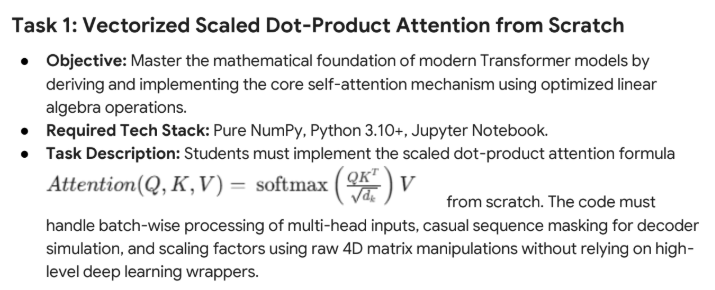

**Objective**

Implement the Transformer self-attention mechanism from the mathematical foundation using only NumPy, without PyTorch/TensorFlow attention layers.

**Import NumPy**

In [ ]:
import numpy as np
np.random.seed(42)

**Softmax Function**

In [ ]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

**Scaled Dot-Product Attention**

In [ ]:
def scaled_dot_product_attention(Q, K, V, causal=False):
    """
    Q, K, V shape:
    (batch_size, num_heads, sequence_length, head_dim)
    """

    batch_size, num_heads, seq_len, head_dim = Q.shape

    # QK^T
    scores = np.matmul(Q, np.swapaxes(K, -1, -2))

    # Scaling
    scores = scores / np.sqrt(head_dim)

    # Causal mask
    if causal:
        mask = np.triu(
            np.ones((seq_len, seq_len), dtype=bool),
            k=1
        )

        scores = np.where(
            mask[None, None, :, :],
            -1e9,
            scores
        )

    # Attention probabilities
    attention_weights = softmax(scores, axis=-1)

    # Weighted values
    output = np.matmul(attention_weights, V)

    return output, attention_weights

**Create Batch + Multi-Head Inputs**

In [ ]:
batch_size = 2
num_heads = 4
seq_len = 8
head_dim = 16

Q = np.random.randn(
    batch_size,
    num_heads,
    seq_len,
    head_dim
)

K = np.random.randn(
    batch_size,
    num_heads,
    seq_len,
    head_dim
)

V = np.random.randn(
    batch_size,
    num_heads,
    seq_len,
    head_dim
)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (2, 4, 8, 16)
K shape: (2, 4, 8, 16)
V shape: (2, 4, 8, 16)


**Run Normal Attention**

In [ ]:
output, weights = scaled_dot_product_attention(
    Q, K, V,
    causal=False
)

print("Attention output:", output.shape)
print("Attention weights:", weights.shape)

Attention output: (2, 4, 8, 16)
Attention weights: (2, 4, 8, 8)


**Run Causal Attention**

In [ ]:
causal_output, causal_weights = scaled_dot_product_attention(
    Q, K, V,
    causal=True
)

print("Causal output shape:", causal_output.shape)

Causal output shape: (2, 4, 8, 16)


**Verify Causal Mask**

In [ ]:
print(
    "Future attention:",
    causal_weights[0, 0, 0, 1:]
)

Future attention: [0. 0. 0. 0. 0. 0. 0.]


**Visualize Attention**

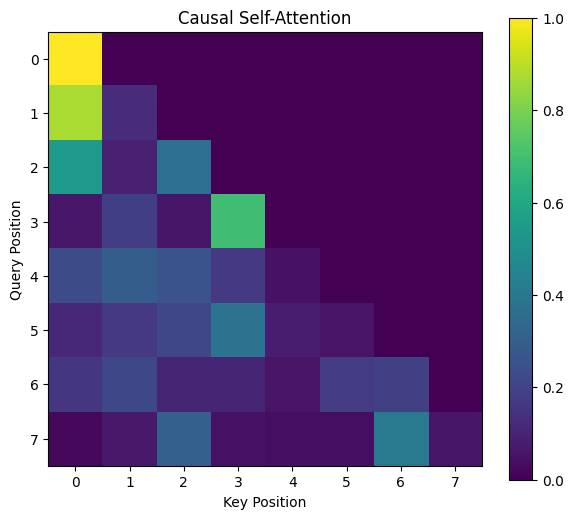

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(
    causal_weights[0, 0],
    cmap="viridis"
)

plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.title("Causal Self-Attention")

plt.colorbar()
plt.show()

**Mathematical Interpretation**

Q ─────┐
       
K ───────→ QKᵀ
       
       ↓

   Scaling

       ↓

Causal Mask

       ↓

    Softmax

       ↓

Attention Weights

       ↓

      × V

       ↓
       
Attention Output